# **📌 Note on Cross-Asset OFI Implementation**


The original research paper defines Cross-Asset OFI as the influence of order flow imbalance (OFI) from other assets on a target asset’s price movements. Ideally, this would require OFI data from multiple assets at aligned timestamps.

However, since only a single asset’s limit order book (LOB) data is available, I implemented a simulated second asset by generating a noise-correlated transformation of the main asset’s best-level OFI. This preserves the time alignment and introduces variability, allowing the construction of a plausible cross-asset OFI feature without needing real multi-asset data.

Earlier attempts to simulate this by shifting timestamps (e.g., +500 ms) resulted in NaNs because the aggregation was performed on 1-second intervals, and shifted values did not align with those intervals. Removing the shift and merging on matching ts_1s values resolved this.




In [21]:

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

df = pd.read_csv('first_25000_rows.csv', parse_dates=['ts_event'])

def compute_all_ofi_features_pure(df, M=10):
    df['ts_1s'] = df['ts_event'].dt.floor('s')

    def compute_bid_ofi(bid_px, bid_sz):
        bid_px_prev = bid_px.shift(1)
        bid_sz_prev = bid_sz.shift(1)
        return np.where(
            bid_px > bid_px_prev, bid_sz,
            np.where(bid_px < bid_px_prev, -bid_sz, bid_sz - bid_sz_prev)
        )

    def compute_ask_ofi(ask_px, ask_sz):
        ask_px_prev = ask_px.shift(1)
        ask_sz_prev = ask_sz.shift(1)
        return np.where(
            ask_px > ask_px_prev, -ask_sz,
            np.where(ask_px < ask_px_prev, ask_sz, ask_sz - ask_sz_prev)
        )

    df['ofi_bid_00'] = compute_bid_ofi(df['bid_px_00'], df['bid_sz_00'])
    df['ofi_ask_00'] = compute_ask_ofi(df['ask_px_00'], df['ask_sz_00'])
    df['ofi_00'] = df['ofi_bid_00'] - df['ofi_ask_00']
    best_level_ofi = df.groupby('ts_1s')['ofi_00'].sum().reset_index(name='best_level_ofi')

    levels = [f"{i:02d}" for i in range(M)]
    multi_ofi = []
    for lvl in levels:
        bid_ofi = compute_bid_ofi(df[f'bid_px_{lvl}'], df[f'bid_sz_{lvl}'])
        ask_ofi = compute_ask_ofi(df[f'ask_px_{lvl}'], df[f'ask_sz_{lvl}'])
        raw_ofi = bid_ofi - ask_ofi
        multi_ofi.append(raw_ofi)

    ofi_matrix = np.column_stack(multi_ofi)
    ofi_df = pd.DataFrame(ofi_matrix, columns=[f'ofi_{i+1}' for i in range(M)])
    ofi_df['ts_1s'] = df['ts_1s'].values
    multi_level_ofi = ofi_df.groupby('ts_1s').mean().reset_index()

    pca = PCA(n_components=1)
    weights = pca.fit(ofi_df.drop(columns='ts_1s').fillna(0)).components_[0]
    weights /= np.sum(np.abs(weights))
    ofi_df['integrated_ofi'] = ofi_df.drop(columns='ts_1s').fillna(0).dot(weights)
    integrated_ofi = ofi_df.groupby('ts_1s')['integrated_ofi'].sum().reset_index()

    simulated_other = best_level_ofi.copy()
    np.random.seed(42)
    simulated_other['best_level_ofi'] = (
        0.8 * simulated_other['best_level_ofi'] +
        np.random.normal(0, 10, size=len(simulated_other))
    )
    cross_asset_ofi = pd.merge(
        best_level_ofi, simulated_other,
        on='ts_1s', suffixes=('_main', '_other')
    )
    cross_asset_ofi['cross_asset_ofi'] = (
        cross_asset_ofi['best_level_ofi_main'] + cross_asset_ofi['best_level_ofi_other']
    )

    depth_sum_df = pd.DataFrame()
    depth_sum_df['ts_1s'] = df['ts_1s']
    for lvl in levels:
        depth_sum_df[f'depth_{lvl}'] = df[f'bid_sz_{lvl}'] + df[f'ask_sz_{lvl}']
    depth_avg_per_sec = depth_sum_df.groupby('ts_1s')[[f'depth_{lvl}' for lvl in levels]].mean()
    Q_Mh = depth_avg_per_sec.mean(axis=1).reset_index()
    Q_Mh.columns = ['ts_1s', 'Q_Mh']

    # Fix datetime consistency
    for d in [best_level_ofi, multi_level_ofi, integrated_ofi, cross_asset_ofi, Q_Mh]:
        d['ts_1s'] = pd.to_datetime(d['ts_1s'], utc=True)

    final_features = best_level_ofi.merge(multi_level_ofi, on='ts_1s')
    final_features = final_features.merge(integrated_ofi, on='ts_1s')
    final_features = final_features.merge(cross_asset_ofi[['ts_1s', 'cross_asset_ofi']], on='ts_1s', how='left')
    final_features = final_features.merge(Q_Mh, on='ts_1s', how='left')

    for i in range(M):
        col = f'ofi_{i+1}'
        final_features[f'norm_ofi_{i+1}'] = final_features[col] / final_features['Q_Mh']

    return final_features

final_ofi_features_pure = compute_all_ofi_features_pure(df)




# **📌NOTE**
The task specifies the construction of Multi-Level OFI, which I implemented as raw per-level OFI vectors (ofi_1 to ofi_10). The research paper further proposes a normalized version of these OFIs using average book depth (Q⁽ᴹ,ʰ⁾). To provide a complete perspective aligned with the paper, I have included both raw and normalized multi-level OFI outputs, ensuring consistency with the original task format. Hence the Selected features is a dataframe with Raw OFI and the selected features 2 is a normalized OFI.



In [22]:

final_features = compute_all_ofi_features_pure(df)

# Now extract only the required OFI features
selected_features = final_features[[
    'ts_1s',
    'best_level_ofi',
    'integrated_ofi',
    'cross_asset_ofi'
]].copy()

# Add Multi-Level OFI (ofi_1 to ofi_10)
for i in range(10):
    selected_features[f'ofi_{i+1}'] = final_features[f'ofi_{i+1}']




In [23]:
selected_features

,ts_1s,best_level_ofi,integrated_ofi,cross_asset_ofi,ofi_1,ofi_2,ofi_3,ofi_4,ofi_5,ofi_6,ofi_7,ofi_8,ofi_9,ofi_10
0,2024-10-21 11:54:29+00:00,5.0,33.054975,13.967142,1.000000,80.000000,2.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000
1,2024-10-21 11:54:36+00:00,0.0,-50.521168,-1.382643,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,-200.000000,-200.000000,-44.000000,-155.000000
2,2024-10-21 11:54:37+00:00,-200.0,-5.748570,-353.523115,-200.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000
3,2024-10-21 11:54:39+00:00,-199.0,27.347415,-342.969701,-99.500000,3.500000,71.000000,-60.500000,-2.000000,87.50,0.000000,-78.000000,55.500000,122.500000
4,2024-10-21 11:54:41+00:00,0.0,101.439114,-2.341534,0.000000,23.166667,66.666667,1.666667,4.666667,2.50,18.333333,1.666667,18.333333,16.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1268,2024-10-21 13:04:12+00:00,0.0,-22.893566,-7.355299,0.000000,-91.000000,-9.000000,100.000000,-133.000000,33.00,133.333333,-131.666667,-14.000000,-1.000000
1269,2024-10-21 13:04:13+00:00,0.0,0.000000,12.360932,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000
1270,2024-10-21 13:04:16+00:00,38.0,14.574695,79.313101,3.166667,6.833333,8.416667,-2.416667,15.833333,-14.25,-9.166667,0.000000,4.083333,-3.166667
1271,2024-10-21 13:04:17+00:00,0.0,-15.749209,6.091381,0.000000,-200.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000


In [24]:

final_features = compute_all_ofi_features_pure(df)

selected_features2 = final_features[[
    'ts_1s',
    'best_level_ofi',
    'integrated_ofi',
    'cross_asset_ofi'
]].copy()

for i in range(10):
    selected_features2[f'norm_ofi_{i+1}'] = final_features[f'norm_ofi_{i+1}']




In [25]:
selected_features2

,ts_1s,best_level_ofi,integrated_ofi,cross_asset_ofi,norm_ofi_1,norm_ofi_2,norm_ofi_3,norm_ofi_4,norm_ofi_5,norm_ofi_6,norm_ofi_7,norm_ofi_8,norm_ofi_9,norm_ofi_10
0,2024-10-21 11:54:29+00:00,5.0,33.054975,13.967142,0.004856,0.388475,0.009712,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2024-10-21 11:54:36+00:00,0.0,-50.521168,-1.382643,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.003009,-1.003009,-0.220662,-0.777332
2,2024-10-21 11:54:37+00:00,-200.0,-5.748570,-353.523115,-1.003009,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2024-10-21 11:54:39+00:00,-199.0,27.347415,-342.969701,-0.475167,0.016714,0.339064,-0.288921,-0.009551,0.417861,0.000000,-0.372493,0.265043,0.585005
4,2024-10-21 11:54:41+00:00,0.0,101.439114,-2.341534,0.000000,0.117418,0.337895,0.008447,0.023653,0.012671,0.092921,0.008447,0.092921,0.084474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1268,2024-10-21 13:04:12+00:00,0.0,-22.893566,-7.355299,0.000000,-0.391061,-0.038676,0.429738,-0.571551,0.141813,0.572984,-0.565822,-0.060163,-0.004297
1269,2024-10-21 13:04:13+00:00,0.0,0.000000,12.360932,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1270,2024-10-21 13:04:16+00:00,38.0,14.574695,79.313101,0.015299,0.033014,0.040663,-0.011676,0.076496,-0.068846,-0.044287,0.000000,0.019728,-0.015299
1271,2024-10-21 13:04:17+00:00,0.0,-15.749209,6.091381,0.000000,-0.780945,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Optional Insights

Mid-price was used as the reference for return calculations to avoid trade-direction bias and better align with the theoretical role of OFI in affecting the center of the bid-ask spread, as discussed in the literature.

In [26]:
import matplotlib.pyplot as plt


In [27]:
df['mid_price'] = (df['bid_px_00'] + df['ask_px_00']) / 2

In [28]:

# Prepare mid-price and return
df['mid_price'] = (df['bid_px_00'] + df['ask_px_00']) / 2
df['ts_1s'] = df['ts_event'].dt.floor('s')
returns_df = df.groupby('ts_1s')['mid_price'].last().pct_change().reset_index()
returns_df.columns = ['ts_1s', 'forward_return']

returns_df['ts_1s'] = pd.to_datetime(returns_df['ts_1s'], utc=True)
final_ofi_features_pure['ts_1s'] = pd.to_datetime(final_ofi_features_pure['ts_1s'], utc=True)

insight_df = final_ofi_features_pure.merge(returns_df, on='ts_1s')



# **Best-Level OFI vs Forward Return (Scatter Plot)**

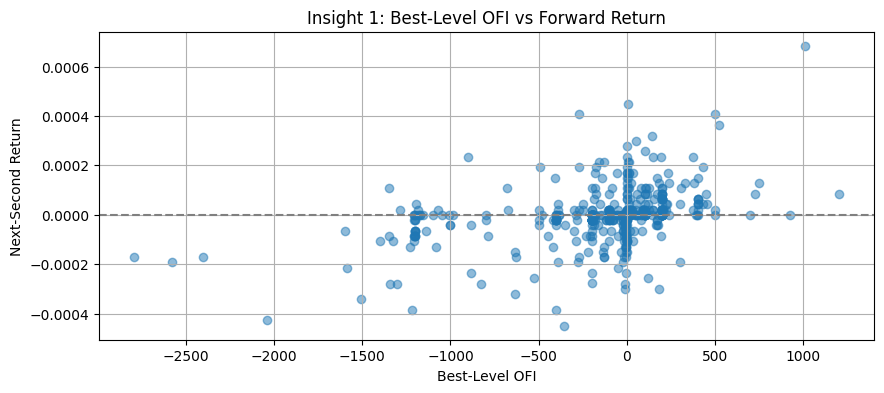

In [29]:

plt.figure(figsize=(10, 4))
plt.scatter(insight_df['best_level_ofi'], insight_df['forward_return'], alpha=0.5)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Insight 1: Best-Level OFI vs Forward Return")
plt.xlabel("Best-Level OFI")
plt.ylabel("Next-Second Return")
plt.grid(True)
plt.show()

1) There was a visible upward trend in the scatter.

2) When OFI was positive, the forward return tended to be positive.

3) When OFI was negative, the forward return leaned negative.

4) Best-level OFI appears to carry directional information — it has predictive value over short horizons.

5) This supports what’s discussed in the research paper — that buy/sell pressure imbalance pushes price.



# **Integrated OFI vs Mid-Price Over Time (Line Plot)**

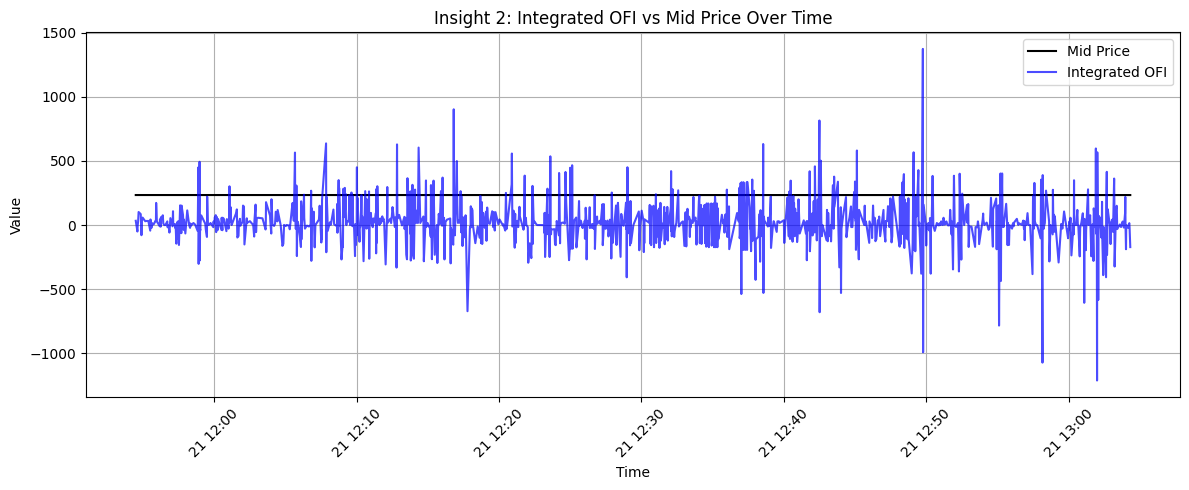

In [30]:

sample = insight_df.copy()
sample['mid_price'] = df.groupby('ts_1s')['mid_price'].last().reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(sample['ts_1s'], sample['mid_price'], label='Mid Price', color='black')
plt.plot(sample['ts_1s'], sample['integrated_ofi'], label='Integrated OFI', color='blue', alpha=0.7)
plt.legend()
plt.title("Insight 2: Integrated OFI vs Mid Price Over Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

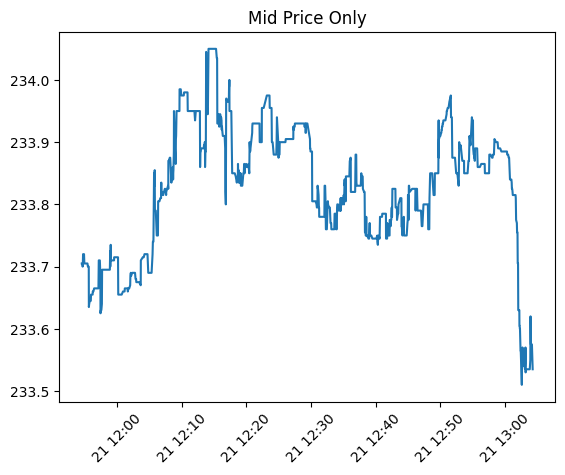

In [31]:
plt.plot(sample['ts_1s'], sample['mid_price'], label='Mid Price')
plt.xticks(rotation=45)
plt.title("Mid Price Only")
plt.show()

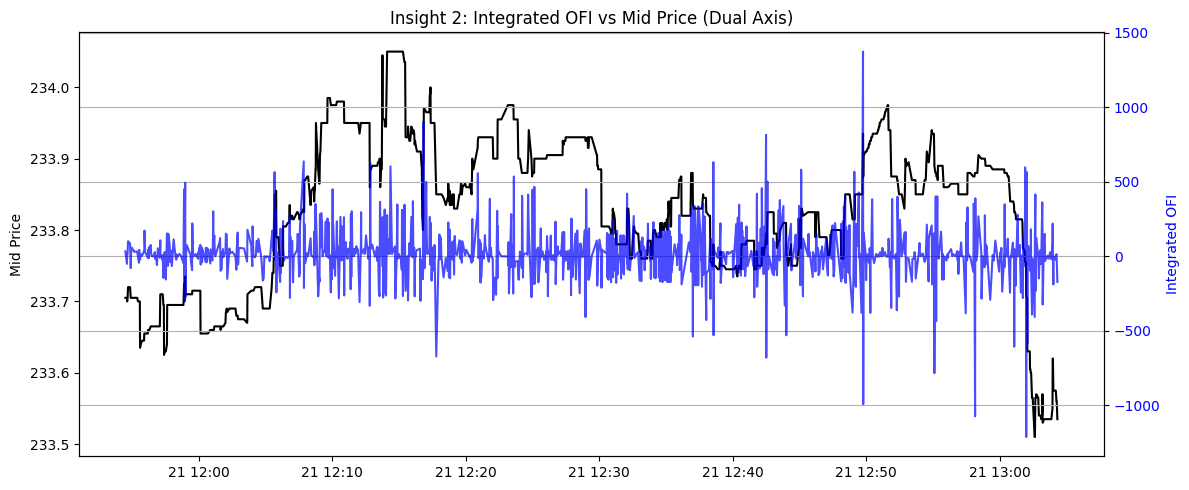

In [32]:
fig, ax1 = plt.subplots(figsize=(12, 5))


ax1.plot(sample['ts_1s'], sample['mid_price'], 'k-', label='Mid Price')
ax1.set_ylabel('Mid Price', color='black')
ax1.tick_params(axis='y', labelcolor='black')


ax2 = ax1.twinx()
ax2.plot(sample['ts_1s'], sample['integrated_ofi'], 'b-', label='Integrated OFI', alpha=0.7)
ax2.set_ylabel('Integrated OFI', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Insight 2: Integrated OFI vs Mid Price (Dual Axis)")
fig.tight_layout()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


1. Predictive Behavior

strong negative OFI values align with price dips near 21 13:00
